In [1]:
# =========================================================
# Global Air Pollution — AQI Category Classification
# Algorithms: Decision Tree, Random Forest, XGBoost, SVM
# Each algorithm is trained and evaluated in its OWN section
# Run this cell-by-cell in Google Colab
# =========================================================


# =========================================================
# SECTION 0: Setup — install & import libraries
# =========================================================
!pip install xgboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

In [2]:
# =========================================================
# SECTION 1: Load and clean the dataset
# =========================================================
from google.colab import files
uploaded = files.upload()   # choose global_air_pollution_data.csv when prompted

df = pd.read_csv("/content/global_air_pollution_data.csv")

# Clean column names (removes stray tabs/spaces/BOM characters)
df.columns = df.columns.str.strip().str.replace("\t", "", regex=False)
df.columns = df.columns.str.replace("ï»¿", "", regex=False)

# Drop rows with a missing target
df = df.dropna(subset=["aqi_category"])

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Saving global_air_pollution_data.csv to global_air_pollution_data.csv
Columns: ['country_name', 'city_name', 'aqi_value', 'aqi_category', 'co_aqi_value', 'co_aqi_category', 'ozone_aqi_value', 'ozone_aqi_category', 'no2_aqi_value', 'no2_aqi_category', 'pm2.5_aqi_value', 'pm2.5_aqi_category']
Shape: (23463, 12)


,country_name,city_name,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [3]:
# =========================================================
# SECTION 1: Load and clean the dataset
# =========================================================
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()   # choose global_air_pollution_data.csv when prompted

# Use whatever filename Colab actually saved (avoids the "(1).csv" mismatch
# that happens if you upload more than once in the same session)
uploaded_filename = list(uploaded.keys())[0]

# encoding="utf-8-sig" strips the BOM properly -- more robust than trying
# to string-replace the mojibake "ï»¿" pattern, which only works if the
# BOM happens to get mis-decoded that specific way
df = pd.read_csv(uploaded_filename, encoding="utf-8-sig")

# ---- Clean column names (stray tabs / spaces) ----
df.columns = df.columns.str.strip().str.replace("\t", "", regex=False)

# Rename the pm2.5 columns to underscore form so they're valid Python
# identifiers later (df.pm25_aqi_value, feature lists, etc.)
df = df.rename(columns={
    "pm2.5_aqi_value": "pm25_aqi_value",
    "pm2.5_aqi_category": "pm25_aqi_category",
})

# Standard AQI category order, low severity -> high severity.
# Used both to validate labels and later for ordinal encoding if needed.
AQI_CATEGORY_ORDER = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous",
]

# ---- Strip whitespace from all text columns ----
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

# ---- Drop rows with a missing target (can't train/evaluate without it) ----
before = len(df)
df = df.dropna(subset=["aqi_category"])
print(f"Dropped {before - len(df)} rows with missing target (aqi_category).")

# ---- Normalize target label casing/typos to the canonical set ----
df["aqi_category"] = df["aqi_category"].str.title().replace({
    "Unhealthy For Sensitive Groups": "Unhealthy for Sensitive Groups"
})
invalid_mask = ~df["aqi_category"].isin(AQI_CATEGORY_ORDER)
if invalid_mask.any():
    print(f"Dropping {invalid_mask.sum()} rows with an unrecognized aqi_category label.")
    df = df[~invalid_mask]

# ---- Handle missing values in non-target columns ----
# country_name / city_name: fill rather than drop, since the AQI readings
# themselves are still valid for these rows.
df["country_name"] = df["country_name"].fillna("Unknown")
df["city_name"] = df["city_name"].fillna("Unknown")

# ---- Numeric feature columns: coerce to numeric + clip to valid AQI range ----
numeric_cols = ["aqi_value", "co_aqi_value", "ozone_aqi_value",
                "no2_aqi_value", "pm25_aqi_value"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].clip(lower=0, upper=500)

# Drop any rows where a feature column became NaN after coercion
# (i.e. it originally held a non-numeric/junk value)
before = len(df)
df = df.dropna(subset=numeric_cols)
if len(df) != before:
    print(f"Dropped {before - len(df)} rows with invalid/non-numeric feature values.")

# ---- Remove exact duplicate rows ----
before = len(df)
df = df.drop_duplicates()
if len(df) != before:
    print(f"Removed {before - len(df)} exact duplicate rows.")

# ---- Reset index after all the dropping ----
df = df.reset_index(drop=True)

print("\nColumns:", df.columns.tolist())
print("Shape:", df.shape)
print("\nRemaining nulls per column:\n", df.isnull().sum())
df.head()

Saving global_air_pollution_data.csv to global_air_pollution_data (1).csv
Dropped 0 rows with missing target (aqi_category).

Columns: ['country_name', 'city_name', 'aqi_value', 'aqi_category', 'co_aqi_value', 'co_aqi_category', 'ozone_aqi_value', 'ozone_aqi_category', 'no2_aqi_value', 'no2_aqi_category', 'pm25_aqi_value', 'pm25_aqi_category']
Shape: (23463, 12)

Remaining nulls per column:
 country_name          0
city_name             0
aqi_value             0
aqi_category          0
co_aqi_value          0
co_aqi_category       0
ozone_aqi_value       0
ozone_aqi_category    0
no2_aqi_value         0
no2_aqi_category      0
pm25_aqi_value        0
pm25_aqi_category     0
dtype: int64


,country_name,city_name,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm25_aqi_value,pm25_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [44]:
# =========================================================
# SECTION 2: Feature/target selection + encoding + split
# =========================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

feature_cols = [
    "co_aqi_value",
    "ozone_aqi_value",
    "no2_aqi_value",
    "pm25_aqi_value"
]
target_col = "aqi_category"

X = df[feature_cols].copy()
y = df[target_col].copy()

# Encode target labels (Good, Moderate, ... -> 0, 1, ...)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", list(le.classes_))

# Train/test split (80/20, stratified so class ratios are preserved)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scaled versions (only needed for SVM, but prepared here once)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, "  Test size:", X_test.shape)

# A dictionary to collect results from every section below,
# used to build the final comparison table at the end.
results = []

Classes: ['Good', 'Hazardous', 'Moderate', 'Unhealthy', 'Unhealthy for Sensitive Groups', 'Very Unhealthy']
Train size: (18770, 4)   Test size: (4693, 4)


In [37]:
print(df[[

    "co_aqi_value",
    "ozone_aqi_value",
    "no2_aqi_value",
    "pm25_aqi_value",

]].head(20))

    co_aqi_value  ozone_aqi_value  no2_aqi_value  pm25_aqi_value
0              1               36              0              51
1              1                5              1              41
2              1               39              2              66
3              1               34              0              20
4              0               22              0               6
5              1               14             11              54
6              1               35              3              62
7              1               29              7              64
8              1               41              1              54
9              3               89              9             142
10             2               68              1              58
11             1               24              6              41
12             3              139              1             158
13             1               50              1             158
14             1         

In [31]:
print(df.describe())

          aqi_value  co_aqi_value  ozone_aqi_value  no2_aqi_value  \
count  23463.000000  23463.000000     23463.000000   23463.000000   
mean      72.010868      1.368367        35.193709       3.063334   
std       56.055220      1.832064        28.098723       5.254108   
min        6.000000      0.000000         0.000000       0.000000   
25%       39.000000      1.000000        21.000000       0.000000   
50%       55.000000      1.000000        31.000000       1.000000   
75%       79.000000      1.000000        40.000000       4.000000   
max      500.000000    133.000000       235.000000      91.000000   

       pm25_aqi_value  
count    23463.000000  
mean        68.519755  
std         54.796443  
min          0.000000  
25%         35.000000  
50%         54.000000  
75%         79.000000  
max        500.000000  


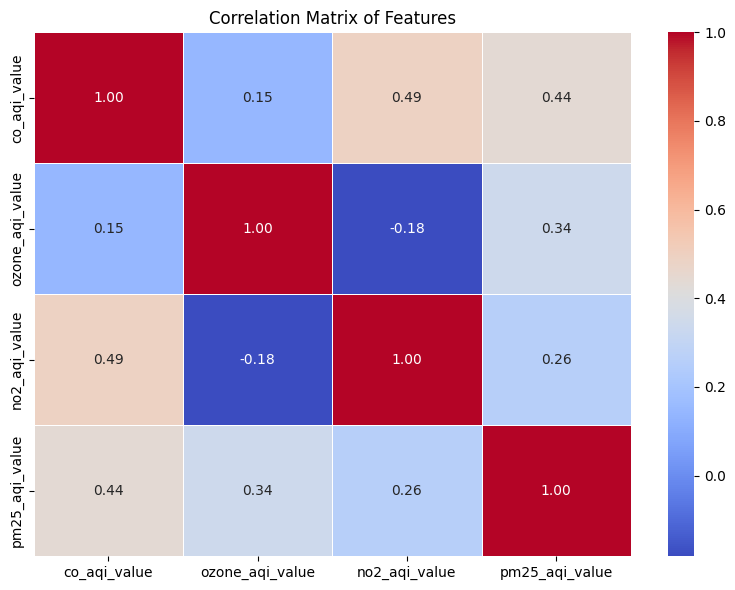

In [45]:
# =========================================================
# SECTION 2A: Correlation Heatmap
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

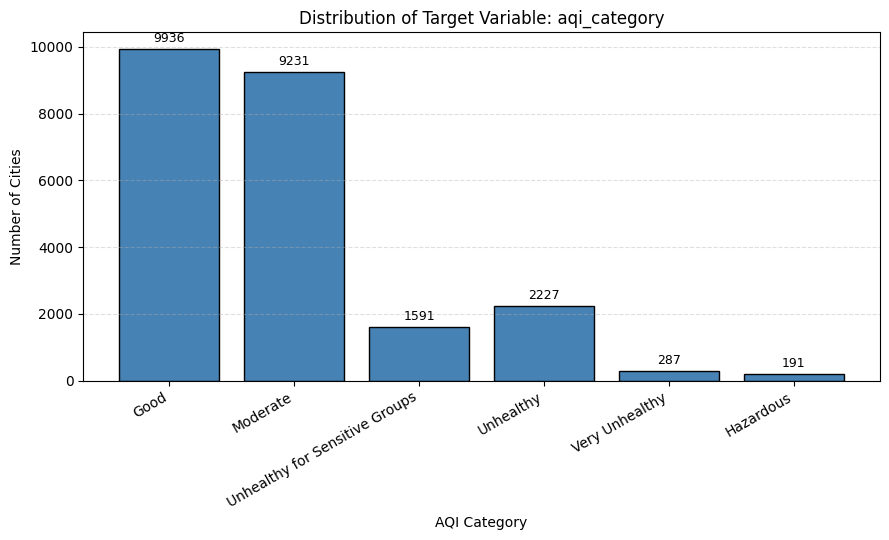

                                Count  Percentage
aqi_category                                     
Good                             9936       42.35
Moderate                         9231       39.34
Unhealthy for Sensitive Groups   1591        6.78
Unhealthy                        2227        9.49
Very Unhealthy                    287        1.22
Hazardous                         191        0.81


In [46]:
# =========================================================
# Target Distribution: aqi_category
# =========================================================
import matplotlib.pyplot as plt

# Keep the bars in severity order (Good -> Hazardous) instead of alphabetical
# or count order, so the chart reads left-to-right as increasing severity.
category_order = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous",
]

counts = df["aqi_category"].value_counts().reindex(category_order)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="black")
ax.bar_label(bars, padding=3, fontsize=9)

ax.set_xlabel("AQI Category")
ax.set_ylabel("Number of Cities")
ax.set_title("Distribution of Target Variable: aqi_category")
plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Also print the exact counts + percentage share of each class
dist_table = counts.to_frame(name="Count")
dist_table["Percentage"] = (dist_table["Count"] / dist_table["Count"].sum() * 100).round(2)
print(dist_table)

In [56]:
# =========================================================
# SECTION 3: Decision Tree
# =========================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average="weighted")
dt_rec = recall_score(y_test, dt_pred, average="weighted")
dt_prec = precision_score(y_test, dt_pred, average="weighted")

print("========== DECISION TREE ==========")
print(f"Accuracy  : {dt_acc:.3f}")
print(f"Precision : {dt_prec:.3f}")
print(f"F1-Score  : {dt_f1:.3f}")
print(f"Recall    : {dt_rec:.3f}")
print("\nDetailed classification report:")
print(classification_report(y_test, dt_pred, target_names=le.classes_))


results.append({"Algorithm": "Decision Tree", "Accuracy": round(dt_acc, 3),
                 "Precision": round(dt_prec, 3), "F1-Score": round(dt_f1, 3),
                 "Recall": round(dt_rec, 3)})

========== DECISION TREE ==========
Accuracy  : 0.990
Precision : 0.985
F1-Score  : 0.987
Recall    : 0.990

Detailed classification report:
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1987
                     Hazardous       0.00      0.00      0.00        38
                      Moderate       1.00      1.00      1.00      1846
                     Unhealthy       0.98      1.00      0.99       446
Unhealthy for Sensitive Groups       1.00      1.00      1.00       318
                Very Unhealthy       0.57      0.88      0.69        58

                      accuracy                           0.99      4693
                     macro avg       0.76      0.81      0.78      4693
                  weighted avg       0.98      0.99      0.99      4693



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

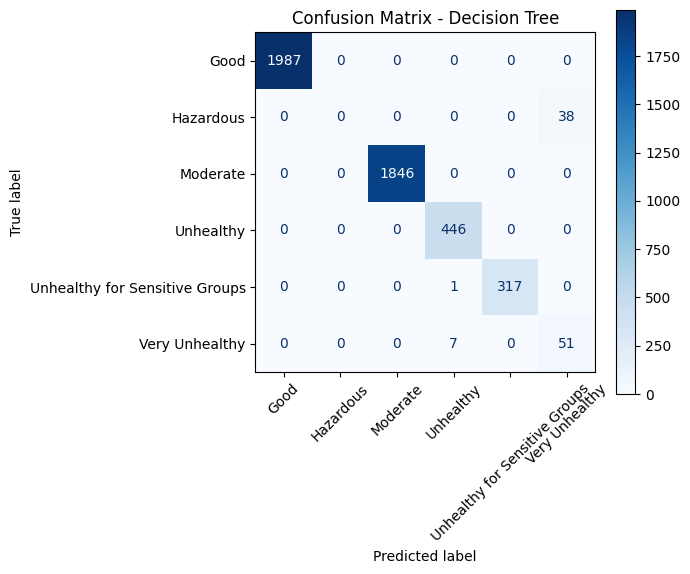

In [57]:
# =========================================================
# Confusion Matrix: Decision Tree
# =========================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, dt_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

In [58]:
# =========================================================
# SECTION 4: Random Forest
# =========================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")
rf_rec = recall_score(y_test, rf_pred, average="weighted")
rf_prec = precision_score(y_test, rf_pred, average="weighted")

print("========== RANDOM FOREST ==========")
print(f"Accuracy  : {rf_acc:.3f}")
print(f"Precision : {rf_prec:.3f}")
print(f"F1-Score  : {rf_f1:.3f}")
print(f"Recall    : {rf_rec:.3f}")
print("\nDetailed classification report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))


results.append({"Algorithm": "Random Forest", "Accuracy": round(rf_acc, 3),
                 "Precision": round(rf_prec, 3), "F1-Score": round(rf_f1, 3),
                 "Recall": round(rf_rec, 3)})

========== RANDOM FOREST ==========
Accuracy  : 0.985
Precision : 0.979
F1-Score  : 0.980
Recall    : 0.985

Detailed classification report:
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1987
                     Hazardous       0.00      0.00      0.00        38
                      Moderate       1.00      1.00      1.00      1846
                     Unhealthy       0.86      1.00      0.93       446
Unhealthy for Sensitive Groups       1.00      1.00      1.00       318
                Very Unhealthy       1.00      0.45      0.62        58

                      accuracy                           0.98      4693
                     macro avg       0.81      0.74      0.76      4693
                  weighted avg       0.98      0.98      0.98      4693



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

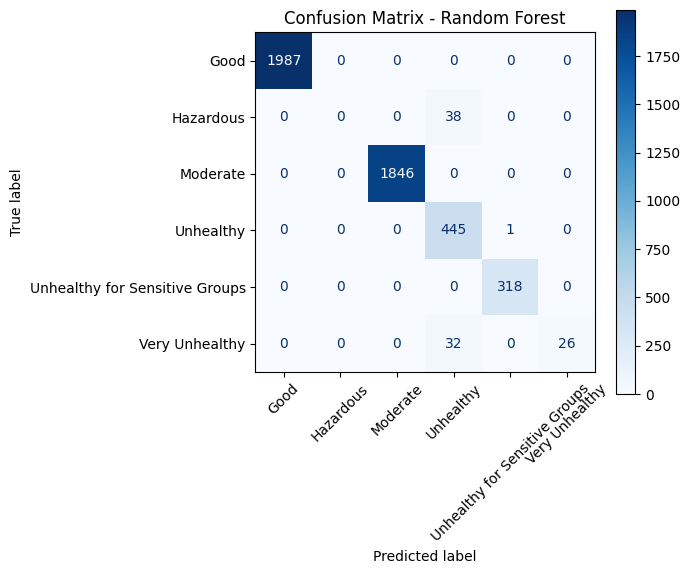

In [59]:
# =========================================================
# Confusion Matrix: Random Forest
# =========================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [61]:
# =========================================================
# SECTION 5: XGBoost
# =========================================================
!pip install -q xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.3,
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")
xgb_rec = recall_score(y_test, xgb_pred, average="weighted")
xgb_prec = precision_score(y_test, xgb_pred, average="weighted")

print("========== XGBOOST ==========")
print(f"Accuracy  : {xgb_acc:.3f}")
print(f"Precision : {xgb_prec:.3f}")
print(f"F1-Score  : {xgb_f1:.3f}")
print(f"Recall    : {xgb_rec:.3f}")
print("\nDetailed classification report:")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

results.append({"Algorithm": "XGBoost", "Accuracy": round(xgb_acc, 3),
                 "Precision": round(xgb_prec, 3), "F1-Score": round(xgb_f1, 3),
                 "Recall": round(xgb_rec, 3)})

========== XGBOOST ==========
Accuracy  : 0.998
Precision : 0.998
F1-Score  : 0.998
Recall    : 0.998

Detailed classification report:
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1987
                     Hazardous       0.89      0.87      0.88        38
                      Moderate       1.00      1.00      1.00      1846
                     Unhealthy       1.00      1.00      1.00       446
Unhealthy for Sensitive Groups       1.00      1.00      1.00       318
                Very Unhealthy       0.92      0.93      0.92        58

                      accuracy                           1.00      4693
                     macro avg       0.97      0.97      0.97      4693
                  weighted avg       1.00      1.00      1.00      4693



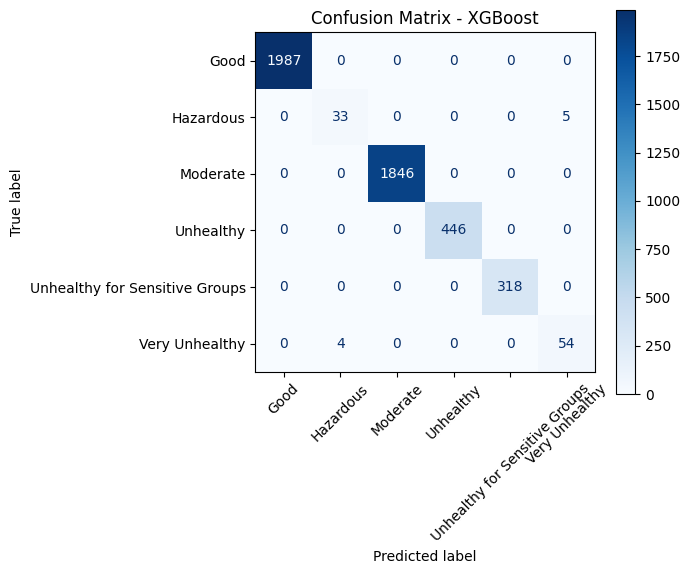

In [62]:
# =========================================================
# Confusion Matrix: XGBoost
# =========================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, xgb_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

In [53]:
# =========================================================
# SECTION 6: SVM
# =========================================================
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

# SVM is distance-based, so it needs the SCALED features (X_train_scaled /
# X_test_scaled from Section 2) rather than the raw X_train / X_test used
# by the tree-based models above.
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred, average="weighted")
svm_rec = recall_score(y_test, svm_pred, average="weighted")
svm_prec = precision_score(y_test, svm_pred, average="weighted")

print("========== SVM ==========")
print(f"Accuracy  : {svm_acc:.3f}")
print(f"Precision : {svm_prec:.3f}")
print(f"F1-Score  : {svm_f1:.3f}")
print(f"Recall    : {svm_rec:.3f}")
print("\nDetailed classification report:")
print(classification_report(y_test, svm_pred, target_names=le.classes_))

results.append({"Algorithm": "SVM", "Accuracy": round(svm_acc, 3),
                 "Precision": round(svm_prec, 3), "F1-Score": round(svm_f1, 3),
                 "Recall": round(svm_rec, 3)})

========== SVM ==========
Accuracy  : 0.986
Precision : 0.987
F1-Score  : 0.986
Recall    : 0.986

Detailed classification report:
                                precision    recall  f1-score   support

                          Good       1.00      0.99      0.99      1987
                     Hazardous       0.95      0.92      0.93        38
                      Moderate       0.99      0.99      0.99      1846
                     Unhealthy       0.96      0.99      0.98       446
Unhealthy for Sensitive Groups       0.99      0.94      0.97       318
                Very Unhealthy       0.85      0.91      0.88        58

                      accuracy                           0.99      4693
                     macro avg       0.96      0.96      0.96      4693
                  weighted avg       0.99      0.99      0.99      4693



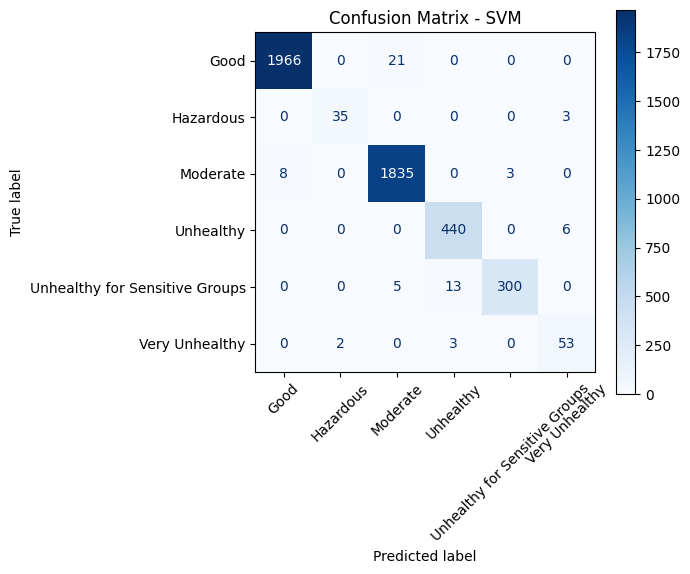

In [54]:
# =========================================================
# Confusion Matrix: SVM
# =========================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, svm_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix - SVM")
plt.tight_layout()
plt.show()


========== MODEL COMPARISON ==========
    Algorithm  Accuracy  Precision  F1-Score  Recall
      XGBoost     0.998      0.998     0.998   0.998
Decision Tree     0.990      0.985     0.987   0.990
          SVM     0.986      0.987     0.986   0.986
Random Forest     0.985      0.979     0.980   0.985

Best Accuracy  : XGBoost (0.998)
Best Precision : XGBoost (0.998)
Best F1-Score  : XGBoost (0.998)
Best Recall    : XGBoost (0.998)


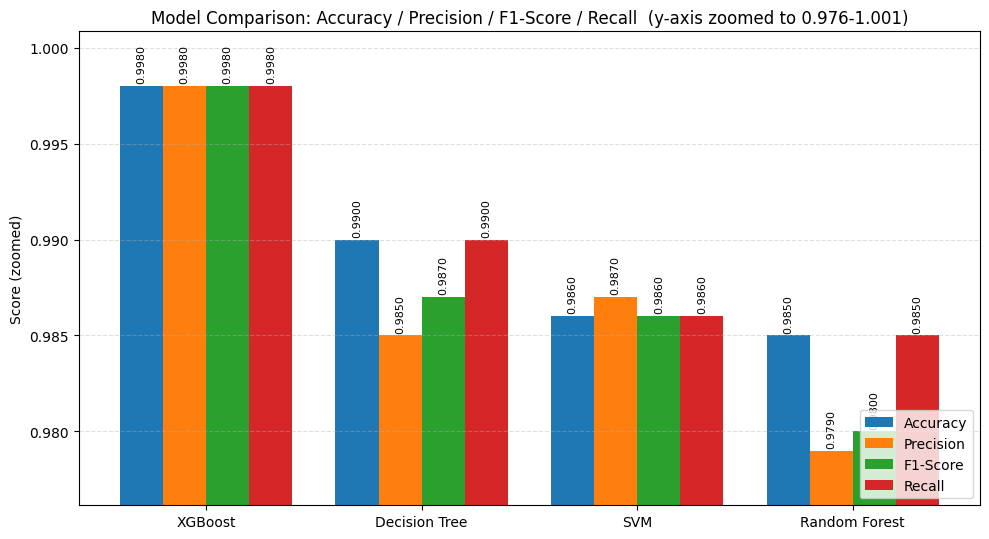

,Algorithm,Accuracy,Precision,F1-Score,Recall
0,XGBoost,0.998,0.998,0.998,0.998
1,Decision Tree,0.990,0.985,0.987,0.990
2,SVM,0.986,0.987,0.986,0.986
3,Random Forest,0.985,0.979,0.980,0.985


In [63]:
# =========================================================
# SECTION 7: Final comparison table
# =========================================================
import pandas as pd
import matplotlib.pyplot as plt

# Keep only the LATEST entry per algorithm, in case a section cell was
# re-run and appended duplicate rows to `results`.
results_df = pd.DataFrame(results).drop_duplicates(subset="Algorithm", keep="last")

# Sort by Accuracy (highest first) so the best model is at the top
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("========== MODEL COMPARISON ==========")
print(results_df.to_string(index=False))

# Highlight the best model per metric
best_acc = results_df.loc[results_df["Accuracy"].idxmax()]
best_prec = results_df.loc[results_df["Precision"].idxmax()]
best_f1 = results_df.loc[results_df["F1-Score"].idxmax()]
best_rec = results_df.loc[results_df["Recall"].idxmax()]

print(f"\nBest Accuracy  : {best_acc['Algorithm']} ({best_acc['Accuracy']})")
print(f"Best Precision : {best_prec['Algorithm']} ({best_prec['Precision']})")
print(f"Best F1-Score  : {best_f1['Algorithm']} ({best_f1['F1-Score']})")
print(f"Best Recall    : {best_rec['Algorithm']} ({best_rec['Recall']})")

# ---- Bar chart comparing all 4 metrics across all models ----
metrics = ["Accuracy", "Precision", "F1-Score", "Recall"]
x = range(len(results_df))
width = 0.2  # narrower now that there are 4 bars per model instead of 3

# All scores are clustered near 1.0, so a 0-1.1 axis would flatten every
# bar to look identical. Instead, zoom the y-axis to just above/below the
# actual min/max values so the real differences become visible.
all_values = results_df[metrics].values.flatten()
y_min = all_values.min()
y_max = all_values.max()
margin = max((y_max - y_min) * 0.15, 0.002)  # small padding, never zero
y_low = max(0, y_min - margin)
y_high = min(1.02, y_max + margin)

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width  # centers the 4 bars around each tick
    bars = ax.bar([p + offset for p in x], results_df[metric], width, label=metric)
    # 4 decimal places so tiny gaps (e.g. 0.999 vs 1.000) are readable on the labels
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8, rotation=90)

ax.set_xticks(list(x))
ax.set_xticklabels(results_df["Algorithm"])
ax.set_ylim(y_low, y_high)
ax.set_ylabel("Score (zoomed)")
ax.set_title(f"Model Comparison: Accuracy / Precision / F1-Score / Recall  (y-axis zoomed to {y_low:.3f}-{y_high:.3f})")
ax.grid(axis="y", linestyle="--", alpha=0.4)  # gridlines make small gaps easier to read
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

results_df

========== MODEL COMPARISON ==========

       Algorithm  Accuracy  Precision  F1-Score  Recall
0  Decision Tree     0.990      0.985     0.987   0.990
1  Random Forest     0.985      0.979     0.980   0.985
2        XGBoost     0.998      0.998     0.998   0.998
3            SVM     0.986      0.987     0.986   0.986

Best Accuracy  : XGBoost (0.998)
Best Precision : XGBoost (0.998)
Best F1-Score  : XGBoost (0.998)
Best Recall    : XGBoost (0.998)


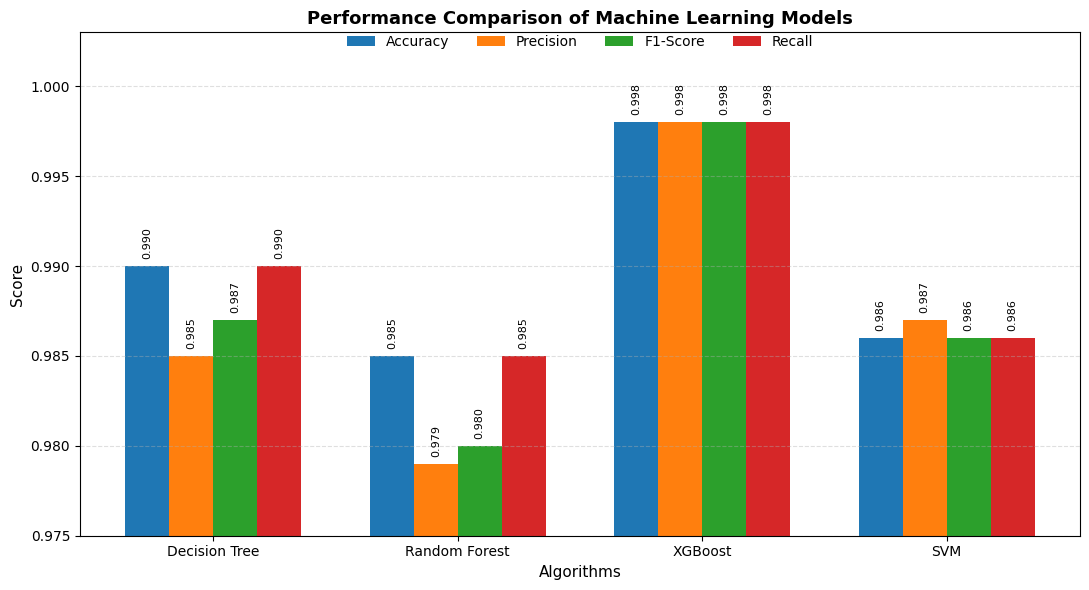

,Algorithm,Accuracy,Precision,F1-Score,Recall
0,Decision Tree,0.990,0.985,0.987,0.990
1,Random Forest,0.985,0.979,0.980,0.985
2,XGBoost,0.998,0.998,0.998,0.998
3,SVM,0.986,0.987,0.986,0.986


In [68]:
# =========================================================
# SECTION 8: Final Comparison Graph
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Create Results DataFrame
# ---------------------------------------------------------
results_df = pd.DataFrame(results)

# Remove duplicate entries if any
results_df = results_df.drop_duplicates(
    subset="Algorithm",
    keep="last"
)

# Desired order
order = [
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "SVM",
    "Soft Voting"
]

# Keep only available algorithms
results_df = results_df[
    results_df["Algorithm"].isin(order)
]

# Arrange in desired order
results_df["Algorithm"] = pd.Categorical(
    results_df["Algorithm"],
    categories=order,
    ordered=True
)

results_df = results_df.sort_values("Algorithm").reset_index(drop=True)

print("========== MODEL COMPARISON ==========\n")
print(results_df)

# ---------------------------------------------------------
# Best Models
# ---------------------------------------------------------
best_acc = results_df.loc[results_df["Accuracy"].idxmax()]
best_prec = results_df.loc[results_df["Precision"].idxmax()]
best_f1 = results_df.loc[results_df["F1-Score"].idxmax()]
best_rec = results_df.loc[results_df["Recall"].idxmax()]

print(f"\nBest Accuracy  : {best_acc['Algorithm']} ({best_acc['Accuracy']:.3f})")
print(f"Best Precision : {best_prec['Algorithm']} ({best_prec['Precision']:.3f})")
print(f"Best F1-Score  : {best_f1['Algorithm']} ({best_f1['F1-Score']:.3f})")
print(f"Best Recall    : {best_rec['Algorithm']} ({best_rec['Recall']:.3f})")

# =========================================================
# Performance Comparison Graph
# =========================================================

metrics = ["Accuracy", "Precision", "F1-Score", "Recall"]

x = np.arange(len(results_df))
width = 0.18

fig, ax = plt.subplots(figsize=(11,6))

bars1 = ax.bar(x-1.5*width, results_df["Accuracy"], width, label="Accuracy")
bars2 = ax.bar(x-0.5*width, results_df["Precision"], width, label="Precision")
bars3 = ax.bar(x+0.5*width, results_df["F1-Score"], width, label="F1-Score")
bars4 = ax.bar(x+1.5*width, results_df["Recall"], width, label="Recall")

# ---------------------------------------------------------
# Value Labels
# ---------------------------------------------------------
for bars in [bars1, bars2, bars3, bars4]:
    ax.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        rotation=90,
        padding=5
    )

# ---------------------------------------------------------
# Axis Formatting
# ---------------------------------------------------------
all_scores = results_df[metrics].values.flatten()

ymin = all_scores.min()
ymax = all_scores.max()

ax.set_ylim(ymin-0.004, ymax+0.005)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Algorithm"], fontsize=10)

ax.set_xlabel("Algorithms", fontsize=11)
ax.set_ylabel("Score", fontsize=11)

ax.set_title(
    "Performance Comparison of Machine Learning Models",
    fontsize=13,
    fontweight="bold"
)

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Display Final Table
# ---------------------------------------------------------
results_df

========== SOFT VOTING ==========
Accuracy  : 0.998
Precision : 0.998
F1-Score  : 0.998
Recall    : 0.998

Detailed Classification Report:

                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1987
                     Hazardous       0.94      0.87      0.90        38
                      Moderate       1.00      1.00      1.00      1846
                     Unhealthy       1.00      1.00      1.00       446
Unhealthy for Sensitive Groups       1.00      1.00      1.00       318
                Very Unhealthy       0.92      0.97      0.94        58

                      accuracy                           1.00      4693
                     macro avg       0.98      0.97      0.97      4693
                  weighted avg       1.00      1.00      1.00      4693



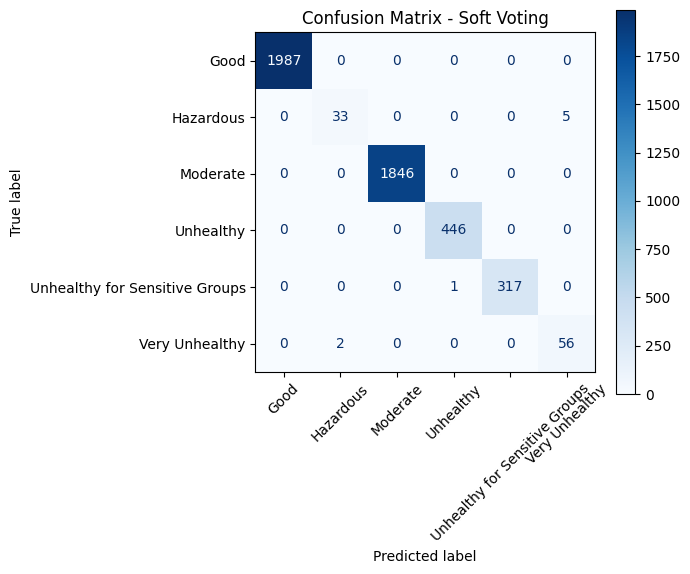

In [69]:
# =========================================================
# SECTION 7: Soft Voting Ensemble
# (Decision Tree + Random Forest + XGBoost)
# =========================================================

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Soft Voting Ensemble
# ---------------------------------------------------------

soft_voting = VotingClassifier(
    estimators=[
    ("dt", dt_model),
    ("xgb", xgb_model),
    ("svm", svm_model)
],
    voting="soft"
)

# ---------------------------------------------------------
# Train
# ---------------------------------------------------------

soft_voting.fit(X_train, y_train)

# ---------------------------------------------------------
# Predict
# ---------------------------------------------------------

soft_pred = soft_voting.predict(X_test)

# ---------------------------------------------------------
# Evaluation
# ---------------------------------------------------------

soft_acc = accuracy_score(y_test, soft_pred)
soft_prec = precision_score(y_test, soft_pred, average="weighted")
soft_f1 = f1_score(y_test, soft_pred, average="weighted")
soft_rec = recall_score(y_test, soft_pred, average="weighted")

print("="*50)
print("========== SOFT VOTING ==========")
print("="*50)

print(f"Accuracy  : {soft_acc:.3f}")
print(f"Precision : {soft_prec:.3f}")
print(f"F1-Score  : {soft_f1:.3f}")
print(f"Recall    : {soft_rec:.3f}")

print("\nDetailed Classification Report:\n")

print(
    classification_report(
        y_test,
        soft_pred,
        target_names=le.classes_
    )
)

# ---------------------------------------------------------
# Store Results
# ---------------------------------------------------------

results.append({
    "Algorithm": "Soft Voting",
    "Accuracy": round(soft_acc,3),
    "Precision": round(soft_prec,3),
    "F1-Score": round(soft_f1,3),
    "Recall": round(soft_rec,3)
})

# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, soft_pred)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Confusion Matrix - Soft Voting")

plt.tight_layout()
plt.show()

MODEL COMPARISON
       Algorithm  Accuracy  Precision  F1-Score  Recall
0    Soft Voting     0.998      0.998     0.998   0.998
1        XGBoost     0.998      0.998     0.998   0.998
2  Decision Tree     0.990      0.985     0.987   0.990
3            SVM     0.986      0.987     0.986   0.986
4  Random Forest     0.985      0.979     0.980   0.985

Best Model
Algorithm : Soft Voting
Accuracy  : 0.998
Precision : 0.998
F1-Score  : 0.998
Recall    : 0.998


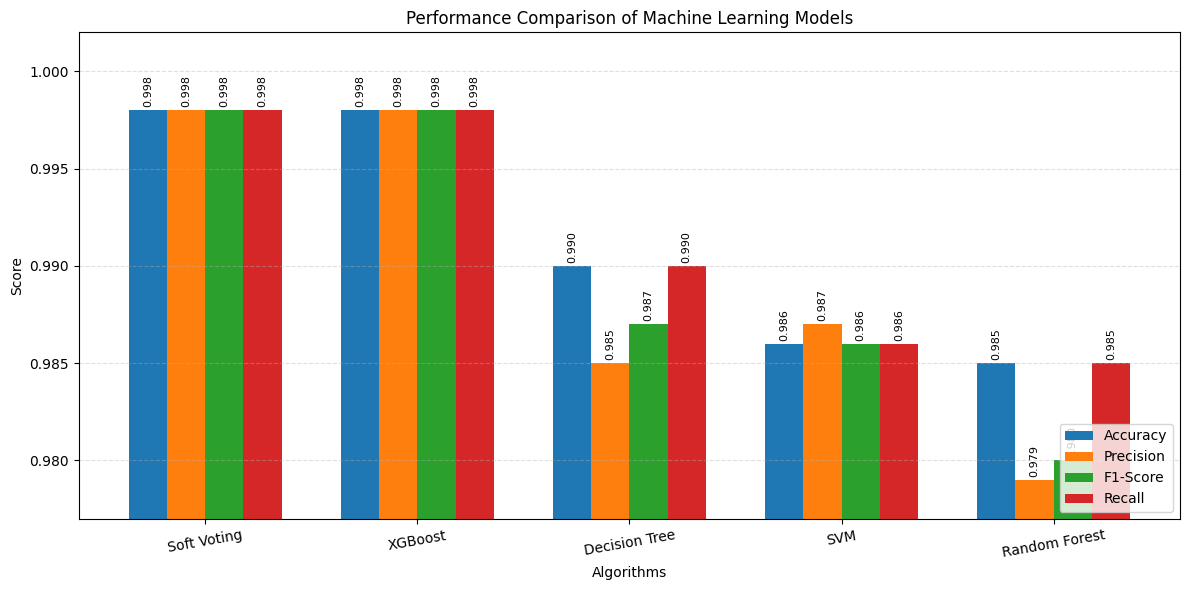

,Algorithm,Accuracy,Precision,F1-Score,Recall
0,Soft Voting,0.998,0.998,0.998,0.998
1,XGBoost,0.998,0.998,0.998,0.998
2,Decision Tree,0.990,0.985,0.987,0.990
3,SVM,0.986,0.987,0.986,0.986
4,Random Forest,0.985,0.979,0.980,0.985


In [70]:
# =========================================================
# SECTION 8: Final Comparison of All Models
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create DataFrame
results_df = pd.DataFrame(results)

# Remove duplicates if any
results_df = results_df.drop_duplicates(subset="Algorithm", keep="last")

# Sort by Accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df)

# -------------------------------
# Best Model
# -------------------------------
best_model = results_df.iloc[0]

print("\nBest Model")
print(f"Algorithm : {best_model['Algorithm']}")
print(f"Accuracy  : {best_model['Accuracy']:.3f}")
print(f"Precision : {best_model['Precision']:.3f}")
print(f"F1-Score  : {best_model['F1-Score']:.3f}")
print(f"Recall    : {best_model['Recall']:.3f}")

# =========================================================
# Comparison Graph
# =========================================================

metrics = ["Accuracy", "Precision", "F1-Score", "Recall"]

x = np.arange(len(results_df))
width = 0.18

fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(x - 1.5*width, results_df["Accuracy"],
               width, label="Accuracy")

bars2 = ax.bar(x - 0.5*width, results_df["Precision"],
               width, label="Precision")

bars3 = ax.bar(x + 0.5*width, results_df["F1-Score"],
               width, label="F1-Score")

bars4 = ax.bar(x + 1.5*width, results_df["Recall"],
               width, label="Recall")

# Value labels
for bars in [bars1, bars2, bars3, bars4]:
    ax.bar_label(
        bars,
        fmt="%.3f",
        fontsize=8,
        rotation=90,
        padding=2
    )

# Zoomed y-axis
minimum = results_df[metrics].min().min()
maximum = results_df[metrics].max().max()

ax.set_ylim(minimum-0.002, 1.002)

ax.set_xticks(x)
ax.set_xticklabels(results_df["Algorithm"], rotation=10)

ax.set_ylabel("Score")
ax.set_xlabel("Algorithms")
ax.set_title("Performance Comparison of Machine Learning Models")

ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# =========================================================
# Display Final Table
# =========================================================

results_df